In [3]:
from typing import Dict, Optional, TypedDict

from pydantic import BaseModel

from langgraph_persona_generator import PersonaPackage, PrivacyAttributes


class GraphState(TypedDict):
    prompt: str
    privacy_attrs: Optional[PrivacyAttributes]
    traces: Optional[Dict[str, BaseModel]]
    persona_package: Optional[PersonaPackage]
    save_dir: Optional[str]


In [4]:
from langgraph.graph import StateGraph, END

from langgraph_persona_generator import generate_privacy_attrs_node, generate_traces_node, package_persona_node, save_package_node


workflow = StateGraph(GraphState)

workflow.add_node("generate_privacy_attrs", generate_privacy_attrs_node)
workflow.add_node("generate_traces", generate_traces_node)
workflow.add_node("package_persona", package_persona_node)
workflow.add_node("save_package", save_package_node)

workflow.set_entry_point("generate_privacy_attrs")
workflow.add_edge("generate_privacy_attrs", "generate_traces")
workflow.add_edge("generate_traces", "package_persona")
workflow.add_edge("package_persona", "save_package")
workflow.add_edge("save_package", END)

app = workflow.compile()

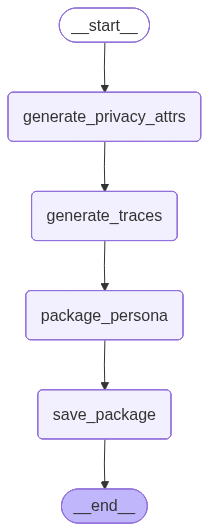

In [5]:
from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_mermaid_png()))